# Extended Statistical Analysis for Cross-Platform LLM Evaluation

This notebook computes additional statistics to address:
- **(i)** Confidence intervals across repeated evaluations
- **(ii)** Sensitivity of conclusions to sampling variance
- **(iii)** Whether differences between models are meaningful in practical or statistical terms

---

## ⚠️ Important: Loading Multiple Models

Since all model results have the same filename (`results.json`), you have **3 options**:

| Option | How | Effort | Best For |
|--------|-----|--------|----------|
| **A. ZIP Upload** | ZIP your `results/` folder, upload once | ⭐ Easy | Most users |
| **B. Clone Repo** | Clone directly from GitHub | ⭐ Easy | Public repos |
| **C. Renamed Files** | Rename each `results.json` before upload | 😓 Tedious | Last resort |

**Recommended: Option A (ZIP Upload)**

## 1. Setup

In [1]:
import numpy as np
from scipy import stats
import json
from collections import defaultdict
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import os
import zipfile
import io

# Initialize results dict
results = {}

print("✓ Dependencies loaded!")

✓ Dependencies loaded!


---
## 2. Load Data (Choose ONE Option)

### 📦 Option A: Upload ZIP File (Recommended)

**Step 1:** On your computer, create a ZIP of your results folder:
```bash
# Navigate to your repository
cd /path/to/crossplatform-llm

# Create ZIP file
zip -r results.zip results/
```

**Step 2:** Run the cell below and upload the ZIP file

In [ ]:
# ========== OPTION A: Upload ZIP file ==========
from google.colab import files

print("📤 Upload your results.zip file...")
print("   (This should contain your results/ folder with all model subfolders)\n")

uploaded = files.upload()

# Extract ZIP
for filename, content in uploaded.items():
    if filename.endswith('.zip'):
        print(f"\n📂 Extracting {filename}...")
        with zipfile.ZipFile(io.BytesIO(content), 'r') as zip_ref:
            zip_ref.extractall('extracted')
        print("✓ Extraction complete!")
        break
else:
    print("⚠️ No ZIP file found! Please upload a .zip file.")

# Find results directory
RESULTS_DIR = None
for root, dirs, files_list in os.walk('extracted'):
    # Look for directories containing results.json files
    for d in dirs:
        potential_result = os.path.join(root, d, 'results.json')
        if os.path.exists(potential_result):
            RESULTS_DIR = root
            break
    if RESULTS_DIR:
        break

# Fallback: check common paths
if not RESULTS_DIR:
    for path in ['extracted/results', 'extracted', 'results']:
        if os.path.exists(path):
            RESULTS_DIR = path
            break

print(f"\n📁 Results directory: {RESULTS_DIR}")
if RESULTS_DIR:
    subdirs = [d for d in os.listdir(RESULTS_DIR) if os.path.isdir(os.path.join(RESULTS_DIR, d))]
    print(f"   Found {len(subdirs)} model folders")

### 🔗 Option B: Clone Repository

If your repository is public, you can clone it directly.

In [2]:
# ========== OPTION B: Clone repository ==========
# Uncomment these lines:

!git clone https://github.com/anonymous/crossplatform-llm.git
RESULTS_DIR = "crossplatform-llm/results"  # This is the correct path
print(f"✓ Cloned! Results dir: {RESULTS_DIR}")

Cloning into 'crossplatform-llm'...
remote: Enumerating objects: 50, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 50 (delta 9), reused 46 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (50/50), 705.84 KiB | 5.74 MiB/s, done.
Resolving deltas: 100% (9/9), done.
✓ Cloned! Results dir: crossplatform-llm/results


### 📄 Option C: Upload Renamed JSON Files

If you can't use ZIP, rename each `results.json` to include the model name:
- `Phi-4-mini_results.json`
- `LLaMA-3.1-8B_results.json`
- etc.

In [ ]:
# ========== OPTION C: Upload renamed JSON files ==========
# Uncomment to use:

# from google.colab import files
# print("📤 Upload your RENAMED JSON files...")
# print("   (e.g., Phi-4-mini_results.json, LLaMA-3.1-8B_results.json)\n")
# uploaded = files.upload()

# for filename, content in uploaded.items():
#     if filename.endswith('.json'):
#         try:
#             data = json.loads(content.decode('utf-8'))
#             model_name = data.get('model', filename.replace('.json', '').replace('_results', ''))
#             results[model_name] = data
#             n_probs = len([e for e in data['evaluations'] if e is not None])
#             print(f"✓ {model_name}: {n_probs} problems")
#         except Exception as e:
#             print(f"✗ Error with {filename}: {e}")

# print(f"\n✓ Loaded {len(results)} models")
# RESULTS_DIR = None  # Mark that we loaded directly

### Load Results from Directory

In [3]:
# Load results from directory (for Options A and B)
# Skip this if you used Option C

if RESULTS_DIR and not results:  # Only run if we have a directory and haven't loaded yet
    print(f"📂 Loading results from: {RESULTS_DIR}\n")

    results_path = Path(RESULTS_DIR)

    # Handle NESTED structure: results/org/model/results.json
    # (e.g., results/microsoft/Phi-4-mini-instruct/results.json)
    for org_dir in sorted(results_path.iterdir()):
        if org_dir.is_dir():
            # Check if results.json is directly here (flat structure)
            direct_result = None
            for fname in ["results.json", "improved_reasoning_evaluation_results.json"]:
                if (org_dir / fname).exists():
                    direct_result = org_dir / fname
                    break

            if direct_result:
                # Flat structure: results/model_folder/results.json
                try:
                    with open(direct_result, 'r') as f:
                        data = json.load(f)
                    model_name = data.get('model', org_dir.name)
                    results[model_name] = data
                    n_probs = len([e for e in data['evaluations'] if e is not None])
                    print(f"  ✓ {model_name}: {n_probs} problems")
                except Exception as e:
                    print(f"  ✗ Error: {e}")
            else:
                # Nested structure: results/org/model/results.json
                for model_dir in sorted(org_dir.iterdir()):
                    if model_dir.is_dir():
                        for fname in ["results.json", "improved_reasoning_evaluation_results.json"]:
                            result_file = model_dir / fname
                            if result_file.exists():
                                try:
                                    with open(result_file, 'r') as f:
                                        data = json.load(f)
                                    model_name = data.get('model', f"{org_dir.name}/{model_dir.name}")
                                    results[model_name] = data
                                    n_probs = len([e for e in data['evaluations'] if e is not None])
                                    print(f"  ✓ {model_name}: {n_probs} problems")
                                except Exception as e:
                                    print(f"  ✗ Error: {e}")
                                break

print(f"\n{'='*60}")
print(f"✅ TOTAL MODELS LOADED: {len(results)}")
print(f"{'='*60}")

if len(results) == 0:
    print("\n⚠️ No models loaded!")
    print("Expected: results/<org>/<model>/results.json")
    print("      or: results/<model>/results.json")

📂 Loading results from: crossplatform-llm/results

  ✓ Qwen/Qwen2-7B-Instruct: 79 problems
  ✓ meta-llama/Meta-Llama-3.1-8B-Instruct: 79 problems
  ✓ microsoft/Phi-3-mini-4k-instruct: 79 problems
  ✓ microsoft/Phi-3.5-MoE-instruct: 79 problems
  ✓ microsoft/Phi-4-mini-instruct: 79 problems
  ✓ mistralai/Mistral-7B-Instruct-v0.1: 79 problems
  ✓ tiiuae/falcon-mamba-7b-instruct: 79 problems

✅ TOTAL MODELS LOADED: 7


---
## 3. Helper Functions

In [4]:
def extract_problem_scores(model_data: dict) -> np.ndarray:
    """Extract per-problem average scores."""
    return np.array([e['average_score'] for e in model_data['evaluations'] if e is not None])

def compute_ci(scores: np.ndarray, confidence: float = 0.95) -> tuple:
    """Parametric confidence interval."""
    n = len(scores)
    if n < 2: return np.mean(scores), np.nan, np.nan, np.nan
    mean, se = np.mean(scores), stats.sem(scores)
    h = se * stats.t.ppf((1 + confidence) / 2, n - 1)
    return mean, mean - h, mean + h, se

def bootstrap_ci(scores: np.ndarray, n_boot: int = 10000, conf: float = 0.95) -> tuple:
    """Bootstrap confidence interval."""
    n = len(scores)
    if n < 2: return np.mean(scores), np.nan, np.nan
    rng = np.random.default_rng(42)
    boot = np.array([np.mean(rng.choice(scores, n, replace=True)) for _ in range(n_boot)])
    alpha = 1 - conf
    return np.mean(scores), np.percentile(boot, 100*alpha/2), np.percentile(boot, 100*(1-alpha/2))

def cohens_d(s1: np.ndarray, s2: np.ndarray) -> float:
    """Cohen's d effect size."""
    n1, n2 = len(s1), len(s2)
    if n1 < 2 or n2 < 2: return np.nan
    pooled = np.sqrt(((n1-1)*np.var(s1,ddof=1) + (n2-1)*np.var(s2,ddof=1)) / (n1+n2-2))
    return (np.mean(s1) - np.mean(s2)) / pooled if pooled > 0 else np.nan

def interpret_d(d: float) -> str:
    """Interpret Cohen's d."""
    if np.isnan(d): return "N/A"
    d = abs(d)
    return "negligible" if d < 0.2 else "small" if d < 0.5 else "medium" if d < 0.8 else "large"

def bootstrap_compare(s1: np.ndarray, s2: np.ndarray, n_boot: int = 10000) -> float:
    """P(model1 > model2) via bootstrap."""
    rng = np.random.default_rng(42)
    wins = sum(np.mean(rng.choice(s1, len(s1), True)) > np.mean(rng.choice(s2, len(s2), True))
               for _ in range(n_boot))
    return wins / n_boot

def welch_test(s1: np.ndarray, s2: np.ndarray) -> tuple:
    """Welch's t-test."""
    if len(s1) < 2 or len(s2) < 2: return np.nan, np.nan
    return stats.ttest_ind(s1, s2, equal_var=False)

def compute_icc(data: dict) -> float:
    """Estimate ICC from score variance."""
    evals = [e for e in data['evaluations'] if e is not None]
    if len(evals) < 2: return np.nan
    means = [e['average_score'] for e in evals]
    within_vars = [e['score_std']**2 for e in evals]
    between = np.var(means, ddof=1)
    within = np.mean(within_vars)
    denom = between + within/3
    return between / denom if denom > 0 else np.nan

def leave_one_domain_out(data: dict) -> dict:
    """Mean score excluding each domain."""
    domain_scores = defaultdict(list)
    for p, e in zip(data['problems'], data['evaluations']):
        if e: domain_scores[p['category']].append(e['average_score'])
    result = {}
    for excl in domain_scores:
        remaining = [s for d, scores in domain_scores.items() if d != excl for s in scores]
        if remaining: result[excl] = np.mean(remaining)
    return result

print("✓ Helper functions loaded!")

✓ Helper functions loaded!


---
## 4. Prepare Data

In [5]:
# Extract scores and sort by performance
model_scores = {name: extract_problem_scores(data) for name, data in results.items()}
sorted_models = sorted(model_scores.keys(), key=lambda m: np.mean(model_scores[m]), reverse=True)

print("📊 Models Ranked by Mean Score:")
print("=" * 65)
for i, m in enumerate(sorted_models, 1):
    scores = model_scores[m]
    print(f"  {i:2d}. {m.split('/')[-1]:<42} {np.mean(scores):.3f} (n={len(scores)})")
print("=" * 65)

📊 Models Ranked by Mean Score:
   1. Phi-3-mini-4k-instruct                     0.565 (n=79)
   2. Phi-4-mini-instruct                        0.560 (n=79)
   3. Meta-Llama-3.1-8B-Instruct                 0.551 (n=79)
   4. Phi-3.5-MoE-instruct                       0.529 (n=79)
   5. Qwen2-7B-Instruct                          0.514 (n=79)
   6. falcon-mamba-7b-instruct                   0.499 (n=79)
   7. Mistral-7B-Instruct-v0.1                   0.388 (n=79)


---
## 5. (i) Confidence Intervals

In [6]:
print("=" * 80)
print("(i) 95% CONFIDENCE INTERVALS")
print("=" * 80)

ci_data = []
for m in sorted_models:
    scores = model_scores[m]
    mean, ci_lo, ci_hi, se = compute_ci(scores)
    _, b_lo, b_hi = bootstrap_ci(scores)
    ci_data.append({
        'Model': m.split('/')[-1][:35],
        'Mean': round(mean, 3),
        'SE': round(se, 3) if not np.isnan(se) else '-',
        '95% CI (Param)': f"[{ci_lo:.3f}, {ci_hi:.3f}]" if not np.isnan(ci_lo) else '-',
        '95% CI (Boot)': f"[{b_lo:.3f}, {b_hi:.3f}]" if not np.isnan(b_lo) else '-'
    })

display(pd.DataFrame(ci_data))

(i) 95% CONFIDENCE INTERVALS


,Model,Mean,SE,95% CI (Param),95% CI (Boot)
0,Phi-3-mini-4k-instruct,0.565,0.025,"[0.515, 0.616]","[0.516, 0.614]"
1,Phi-4-mini-instruct,0.560,0.025,"[0.510, 0.610]","[0.511, 0.609]"
2,Meta-Llama-3.1-8B-Instruct,0.551,0.025,"[0.501, 0.601]","[0.501, 0.600]"
3,Phi-3.5-MoE-instruct,0.529,0.027,"[0.475, 0.582]","[0.477, 0.581]"
4,Qwen2-7B-Instruct,0.514,0.027,"[0.459, 0.569]","[0.461, 0.568]"
5,falcon-mamba-7b-instruct,0.499,0.026,"[0.448, 0.550]","[0.450, 0.549]"
6,Mistral-7B-Instruct-v0.1,0.388,0.027,"[0.335, 0.441]","[0.338, 0.440]"


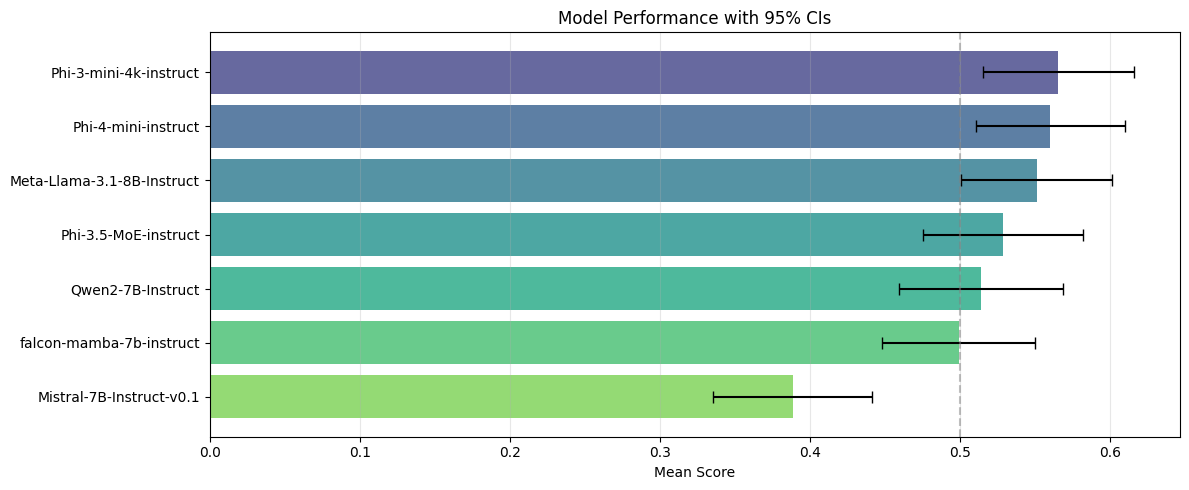

In [7]:
# Visualization
fig, ax = plt.subplots(figsize=(12, max(5, len(sorted_models)*0.5)))
y = np.arange(len(sorted_models))
means = [np.mean(model_scores[m]) for m in sorted_models]
cis = [compute_ci(model_scores[m]) for m in sorted_models]
errs = [[m - ci[1] for m, ci in zip(means, cis)], [ci[2] - m for m, ci in zip(means, cis)]]

ax.barh(y, means, xerr=errs, capsize=4, alpha=0.8, color=plt.cm.viridis(np.linspace(0.2, 0.8, len(y))))
ax.set_yticks(y)
ax.set_yticklabels([m.split('/')[-1][:30] for m in sorted_models])
ax.invert_yaxis()
ax.set_xlabel('Mean Score')
ax.set_title('Model Performance with 95% CIs')
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. (ii) Sensitivity Analysis

In [8]:
print("=" * 80)
print("(ii) SENSITIVITY ANALYSIS")
print("=" * 80)

# ICC
print("\n📊 Intraclass Correlation (ICC)")
print("-" * 50)
iccs = []
for m in sorted_models:
    icc = compute_icc(results[m])
    iccs.append(icc)
    if not np.isnan(icc):
        print(f"  {m.split('/')[-1][:42]:<44} ICC = {icc:.3f}")

valid_iccs = [i for i in iccs if not np.isnan(i)]
if valid_iccs:
    print(f"\n  📈 Mean ICC: {np.mean(valid_iccs):.3f} ({np.mean(valid_iccs)*100:.1f}% variance from problem difficulty)")

(ii) SENSITIVITY ANALYSIS

📊 Intraclass Correlation (ICC)
--------------------------------------------------
  Phi-3-mini-4k-instruct                       ICC = 0.939
  Phi-4-mini-instruct                          ICC = 0.929
  Meta-Llama-3.1-8B-Instruct                   ICC = 0.943
  Phi-3.5-MoE-instruct                         ICC = 0.963
  Qwen2-7B-Instruct                            ICC = 0.974
  falcon-mamba-7b-instruct                     ICC = 0.939
  Mistral-7B-Instruct-v0.1                     ICC = 0.957

  📈 Mean ICC: 0.949 (94.9% variance from problem difficulty)


In [9]:
# Bootstrap comparisons
print("\n📊 Bootstrap Comparisons (10,000 resamples)")
print("-" * 50)

if len(sorted_models) >= 2:
    top = sorted_models[0]
    top_scores = model_scores[top]
    bootstrap_data = []

    for other in sorted_models[1:]:
        p = bootstrap_compare(top_scores, model_scores[other])
        bootstrap_data.append({'vs': other.split('/')[-1][:25], 'P(top wins)': p})
        sym = "✓" if p > 0.5 else "✗"
        print(f"  {sym} P({top.split('/')[-1][:20]:<20} > {other.split('/')[-1][:20]:<20}) = {p:.3f}")


📊 Bootstrap Comparisons (10,000 resamples)
--------------------------------------------------
  ✓ P(Phi-3-mini-4k-instru > Phi-4-mini-instruct ) = 0.559
  ✓ P(Phi-3-mini-4k-instru > Meta-Llama-3.1-8B-In) = 0.667
  ✓ P(Phi-3-mini-4k-instru > Phi-3.5-MoE-instruct) = 0.843
  ✓ P(Phi-3-mini-4k-instru > Qwen2-7B-Instruct   ) = 0.918
  ✓ P(Phi-3-mini-4k-instru > falcon-mamba-7b-inst) = 0.969
  ✓ P(Phi-3-mini-4k-instru > Mistral-7B-Instruct-) = 1.000


In [10]:
# Leave-one-domain-out
print("\n📊 Leave-One-Domain-Out Analysis")
print("-" * 50)

lodo_data = []
if len(sorted_models) >= 2:
    top, second = sorted_models[0], sorted_models[1]
    lodo_top, lodo_second = leave_one_domain_out(results[top]), leave_one_domain_out(results[second])

    if lodo_top and lodo_second:
        print(f"\n  Comparing: {top.split('/')[-1][:30]}")
        print(f"        vs: {second.split('/')[-1][:30]}\n")
        print(f"  {'Excluded':<12} {'Top':>8} {'2nd':>8} {'Δ':>8} {'Winner':>10}")
        print("  " + "-" * 52)

        wins = 0
        for d in sorted(lodo_top.keys()):
            if d in lodo_second:
                delta = lodo_top[d] - lodo_second[d]
                w = "Top ✓" if delta > 0 else "2nd"
                if delta > 0: wins += 1
                print(f"  {d:<12} {lodo_top[d]:>8.3f} {lodo_second[d]:>8.3f} {delta:>+8.3f} {w:>10}")
                lodo_data.append({'Domain': d, 'Top': lodo_top[d], 'Second': lodo_second[d], 'Delta': delta})

        print(f"\n  📈 Top model wins in {wins}/{len(lodo_top)} exclusions ({100*wins/len(lodo_top):.0f}%)")


📊 Leave-One-Domain-Out Analysis
--------------------------------------------------

  Comparing: Phi-3-mini-4k-instruct
        vs: Phi-4-mini-instruct

  Excluded          Top      2nd        Δ     Winner
  ----------------------------------------------------
  Biology         0.563    0.554   +0.009      Top ✓
  Calculus        0.554    0.551   +0.003      Top ✓
  Chemistry       0.568    0.562   +0.006      Top ✓
  Economics       0.559    0.559   +0.001      Top ✓
  Mathematics     0.567    0.561   +0.006      Top ✓
  Optimization    0.577    0.569   +0.009      Top ✓
  Physics         0.561    0.558   +0.002      Top ✓
  Statistics      0.573    0.567   +0.006      Top ✓

  📈 Top model wins in 8/8 exclusions (100%)


---
## 7. (iii) Effect Sizes and Practical Significance

In [11]:
print("=" * 80)
print("(iii) EFFECT SIZES AND PRACTICAL SIGNIFICANCE")
print("=" * 80)

effect_data = []
if len(sorted_models) >= 2:
    top = sorted_models[0]
    top_scores = model_scores[top]

    print(f"\nReference: {top.split('/')[-1]}")
    print("\nEffect sizes: |d|<0.2=negligible, 0.2-0.5=small, 0.5-0.8=medium, ≥0.8=large\n")

    for other in sorted_models[1:]:
        s = model_scores[other]
        delta = np.mean(top_scores) - np.mean(s)
        d = cohens_d(top_scores, s)
        t, p = welch_test(top_scores, s)

        effect_data.append({
            'Model': other.split('/')[-1][:30],
            'Δ Mean': round(delta, 3),
            "Cohen's d": round(d, 3) if not np.isnan(d) else '-',
            'Effect': interpret_d(d),
            'p-value': f"{p:.4f}" if not np.isnan(p) and p >= 0.0001 else '<0.0001' if not np.isnan(p) else '-'
        })

    display(pd.DataFrame(effect_data))

(iii) EFFECT SIZES AND PRACTICAL SIGNIFICANCE

Reference: Phi-3-mini-4k-instruct

Effect sizes: |d|<0.2=negligible, 0.2-0.5=small, 0.5-0.8=medium, ≥0.8=large



,Model,Δ Mean,Cohen's d,Effect,p-value
0,Phi-4-mini-instruct,0.005,0.024,negligible,0.8826
1,Meta-Llama-3.1-8B-Instruct,0.014,0.064,negligible,0.6889
2,Phi-3.5-MoE-instruct,0.037,0.158,negligible,0.3218
3,Qwen2-7B-Instruct,0.051,0.219,small,0.1714
4,falcon-mamba-7b-instruct,0.066,0.293,small,0.0672
5,Mistral-7B-Instruct-v0.1,0.177,0.766,medium,<0.0001


In [12]:
# Practical significance (MPID = 0.05)
MPID = 0.05
print(f"\n📊 Practical Significance (MPID = {MPID})")
print("-" * 50)

if len(sorted_models) >= 2:
    practical = [(m, np.mean(top_scores) - np.mean(model_scores[m]))
                 for m in sorted_models[1:]
                 if abs(np.mean(top_scores) - np.mean(model_scores[m])) >= MPID]

    print(f"\n✓ Practically significant (|Δ| ≥ {MPID}): {len(practical)}")
    for m, d in practical:
        print(f"    vs {m.split('/')[-1][:35]:<37} Δ = {d:+.3f}")

    print(f"\n✗ Not practically significant: {len(sorted_models) - 1 - len(practical)}")


📊 Practical Significance (MPID = 0.05)
--------------------------------------------------

✓ Practically significant (|Δ| ≥ 0.05): 3
    vs Qwen2-7B-Instruct                     Δ = +0.051
    vs falcon-mamba-7b-instruct              Δ = +0.066
    vs Mistral-7B-Instruct-v0.1              Δ = +0.177

✗ Not practically significant: 3


---
## 8. Download Results

In [15]:
# Save and download
output = {
    'confidence_intervals': ci_data,
    'effect_sizes': effect_data,
    'bootstrap_comparisons': bootstrap_data if 'bootstrap_data' in dir() else [],
    'lodo_analysis': lodo_data,
    'summary': {
        'n_models': len(results),
        'n_problems': n_problems,
        'mean_icc': float(np.mean(valid_iccs)) if valid_iccs else None,
        'mean_within_std': float(np.mean(all_stds)) if all_stds else None
    }
}

with open('extended_statistics.json', 'w') as f:
    json.dump(output, f, indent=2, default=lambda x: float(x) if hasattr(x, 'item') else x)

print("✓ Saved to extended_statistics.json")

from google.colab import files
files.download('extended_statistics.json')

✓ Saved to extended_statistics.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>